# Tests de gráficas

Espacio de trabajo para iterar sobre el diseño de las gráficas (colores, tipografía, layout, seaborn vs. matplotlib puro) antes de adaptar lo que funcione a `analysis/comparativo.py`.

No modifica nada de `analysis/`; solo importa las funciones y tablas ya existentes para poder llamar `plt.subplots()` directo desde acá.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
import textwrap

from config import ENTIDADES, RAMOS_DISPONIBLES
from storage.db import load_table

from analysis.descriptive import (
    distribucion_motivo,
    distribucion_por_ramo,
    resumen_ejecutivo,
    volumen_por_entidad_mes,
    volumen_por_trimestre,
)
from analysis.concentracion import (
    indice_desproporcion,
    ramo_con_mayor_crecimiento,
    ranking_mejores,
    ranking_peores,
    tendencia_sector,
)
from analysis.comparativo import (
    plot_motivos_top,
    plot_quejas_por_poliza,
    plot_ranking_desproporcion,
    plot_tendencia_salud,
    plot_tendencia_sector,
)

In [2]:
# Tablas ya limpias, tal como quedaron en data/pqrs_seguros.db tras
# `python run_pipeline.py --stage store` (ver README).
quejas_agrupado = load_table("quejas_agrupado")
quejas_motivo = load_table("quejas_motivo")
joined = load_table("joined")

quejas_agrupado.shape, quejas_motivo.shape, joined.shape

((6261, 4), (46773, 5), (7044, 12))

In [3]:
quejas_motivo

,fecha,entidad,ramo,motivo,cantidad_quejas_recibidas
0,2023-01-01,Alfa,arl,"Demora en la respuesta a quejas, reclamos o pe...",1
1,2023-01-01,Alfa,otros_productos_de_seguros,Demora en la definición de indemnización,1
2,2023-01-01,Alfa,otros_productos_de_seguros,Dificultad en el acceso a la información,1
3,2023-01-01,Alfa,otros_productos_de_seguros,Mal trato por parte de un funcionario,1
4,2023-01-01,Alfa,otros_productos_de_seguros,Otros motivos,14
...,...,...,...,...,...
46768,2026-07-01,Seguros Mundial,seguro_de_cumplimiento,Demora en la autorización de servicios,1
46769,2026-07-01,Seguros Mundial,seguro_de_responsabilidad_civil,Inconformidad con el servicio prestado por el ...,1
46770,2026-07-01,Seguros del Estado,automoviles,Incumplimiento de obligaciones en prestación d...,1
46771,2026-07-01,Seguros del Estado,automoviles,No atención del siniestro,1


## Espacio para iterar

Debajo, celdas sueltas para probar estilos nuevos sobre las mismas tablas (`quejas_agrupado`, `quejas_motivo`, `joined`) y las funciones de agregación de `analysis/descriptive.py` y `analysis/concentracion.py`, sin tocar `analysis/comparativo.py` todavía.

In [5]:
# def plot_motivos_top(df_motivo: pd.DataFrame, ramo: str = "salud", entidad: str | None = None, top_n: int = 10) -> Path:
#     """Barras horizontales con los motivos de queja más frecuentes en el
#     ramo indicado.

#     Sin `entidad`, agrega el sector completo en una sola barra por motivo
#     (vista por defecto: qué está reclamando la gente en este ramo, sin
#     importar la entidad). Pasar `entidad` para el desglose por entidad de
#     una marca puntual (zoom-in), útil solo con pocas entidades a la vez."""
#     tabla = distribucion_motivo(df_motivo, ramo=ramo, entidad=entidad, top_n=top_n)
#     tabla = tabla[["total"]] if entidad is None else tabla.drop(columns="total")

#     OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#     fig, ax = plt.subplots(figsize=(10, 6))
#     tabla.plot(kind="barh", ax=ax, legend=entidad is not None)
#     titulo_entidad = f" - {entidad}" if entidad else " - sector completo"
#     ax.set_title(f"Motivos de queja más frecuentes - ramo {ramo}{titulo_entidad}")
#     ax.set_xlabel("Cantidad de quejas")
#     ax.set_ylabel('')
#     ax.invert_yaxis()
#     fig.tight_layout()

#     sufijo = f"_{entidad}" if entidad else ""
#     ruta = OUTPUT_DIR / f"motivos_top_{ramo}{sufijo}.png"
#     fig.savefig(ruta, dpi=150)
#     plt.close(fig)
#     return ruta

In [96]:
RAMOS_DISPONIBLES

['Seguro de hogar',
 'Seguro de salud',
 'Seguro de vida individual',
 'Seguro de vida grupo',
 'Seguro colectivo de vida',
 'Seguro de riesgos laborales',
 'Seguro de automóviles']

In [135]:
RAMO = "salud"  # cambiar para probar con otro ramo (ver RAMOS_DISPONIBLES)
df = distribucion_motivo(quejas_motivo, ramo=RAMO, top_n=10)[['total']]
# df = df[['total']] if entidad is None else tabla.drop(columns='total')

In [136]:
df_copy = df.copy().reset_index(drop=0)
df_copy['motivo'] = df_copy['motivo'].apply(lambda x: textwrap.fill(x, width=32))
df_copy

entidad,motivo,total
0,Demora en la prestación del\nservicio,9044
1,"Inconformidad con la definición,\nautorización...",4233
2,No prestación del servicio,3534
3,No disponibilidad o fallas de\nlos canales de ...,2826
4,Error en la facturación o cobro\nno pactado,2751
5,Otros motivos,2407
6,Demora en la autorización de\nservicios,2339
7,Vinculación no autorizada,1733
8,Mal trato por parte de un\nfuncionario,1567
9,Mal trato por parte el proveedor,1226


In [137]:
def wrap_labels(labels, width=32):
    return [textwrap.fill(str(l), width=width) for l in labels]

In [138]:
entidad = 0

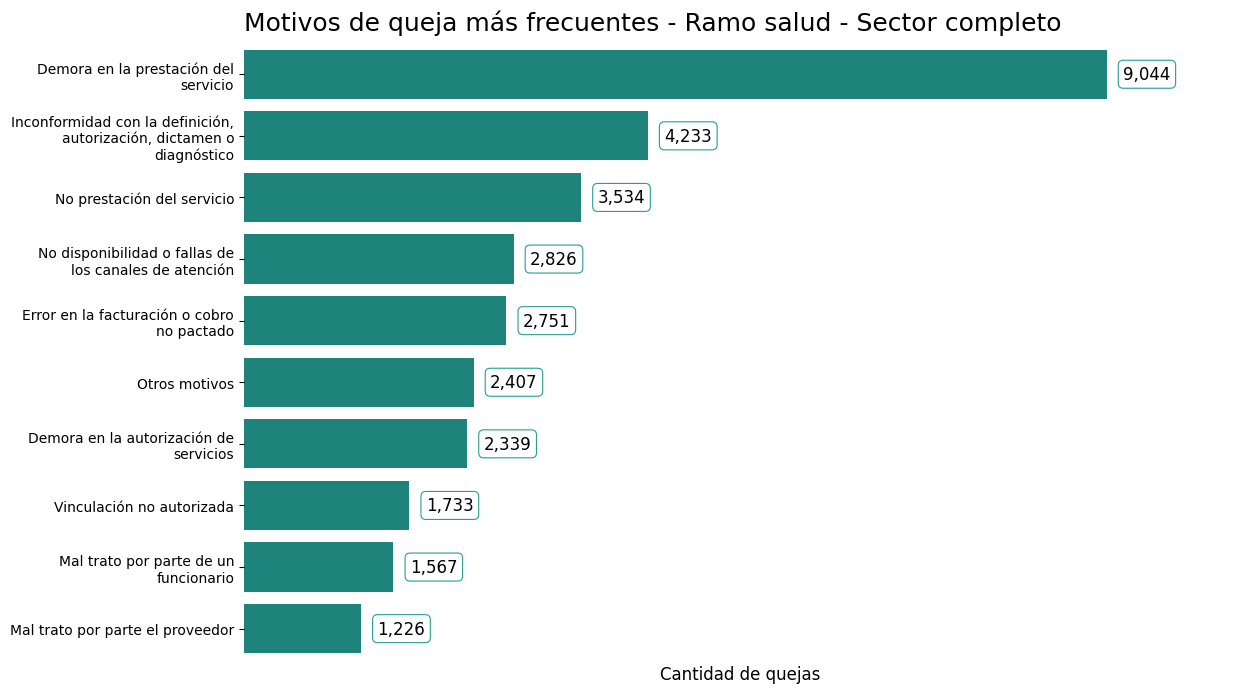

In [139]:
RAMO_COLOR = {
    "hogar": "#D97706",
    "salud": "#0D9488",
    "vida_individual": "#2563EB",
    "vida_grupo": "#4F46E5",       # también cubre "Seguro colectivo de vida" (ver nota arriba)
    "arl": "#EA580C",
    "automoviles": "#DC2626",
}
color_ramo = RAMO_COLOR[RAMO]

plt.figure(figsize=(8 * 1.6, 8))
ax = sns.barplot(
    data=df_copy,
    x='total',
    y='motivo',
    color=color_ramo,
)

for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.annotate(
        f'{width:,.0f}',
        xy=(width, y),
        xytext=(12, 0),
        textcoords='offset points',
        va='center', ha='left',
        fontsize=12,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor=color_ramo,
            linewidth=0.8,
            alpha=0.9,
        ),
    )

plt.title(
    f"Motivos de queja más frecuentes - Ramo {RAMO}{f' - {entidad}' if entidad else ' - Sector completo'}",
    fontsize=18, loc='left', pad=10,
)
plt.xlabel("Cantidad de quejas", fontsize=12)
plt.ylabel('')
plt.xticks([])
plt.xlim(0, df_copy['total'].max() * 1.15)
sns.despine(left=True, bottom=True)